In [27]:
import numpy as np 
import pandas as pd 
import os
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join('..')))
from utils import threshold_utils as tu

In [13]:
models = ['Gradient Boosting_tuned_preds', 'Logistic Regression_preds', 'Random Forest_preds']
for name in models: 
    path = os.path.join('..','outputs','preds',f'{name}.npz')
    data = np.load(path)
    y_test = data['y_test']
    y_pred_proba = data['y_pred_proba']
    s_test = data['s_test'] 
    thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    result =[]
    for t in thresholds: 
        y_pred_adj = tu.adj_threshold(s_test,y_pred_proba,t)
        metrics = tu.eval_subgroups(y_test,y_pred_adj,s_test,t)
        metrics['model'] = name
        result.append(metrics)
    df_results = pd.DataFrame(result)
    
    output_path = os.path.join('..','outputs', 'results', f'{name}_thresholds.csv')
    df_results.to_csv(output_path, index=False)
    print(f"Saved results for {name} → {output_path}")

Saved results for Gradient Boosting_tuned_preds → ..\outputs\results\Gradient Boosting_tuned_preds_thresholds.csv
Saved results for Logistic Regression_preds → ..\outputs\results\Logistic Regression_preds_thresholds.csv
Saved results for Random Forest_preds → ..\outputs\results\Random Forest_preds_thresholds.csv


In [ ]:
results_dir = os.path.join('..', 'outputs', 'results')

all_results = []
try:
    files = [f for f in os.listdir(results_dir) if f.endswith('_thresholds.csv')]
    
    for file in files:
        path = os.path.join(results_dir, file) 
        df = pd.read_csv(path)
        
        all_results.append(df)

except FileNotFoundError:
    print(f"Error: Could not find the results directory. Check path: {results_dir}")
    
# deduplication
if all_results:
    df_all = pd.concat(all_results, ignore_index=True)
    subset_cols = ['women_threshold', 'model', 'overall_accuracy'] 
    df_all_unique = df_all.drop_duplicates(subset=subset_cols, keep='first')
    
    print(f"Original rows: {len(df_all)}. Unique rows: {len(df_all_unique)}")
else:
    df_all_unique = pd.DataFrame()
df_all_unique.head()

Original rows: 21. Unique rows: 21


,women_threshold,hiw_recall,hiw_precision,hiw_f1,hiw_total,hiw_correct,him_recall,liw_specificity,lim_specificity,overall_accuracy,model
0,0.20,0.851064,0.197824,0.321027,235,200,0.701657,0.467975,0.214081,0.697829,Gradient Boosting_tuned_preds
1,0.25,0.778723,0.204241,0.323607,235,183,0.701657,0.411425,0.214081,0.711255,Gradient Boosting_tuned_preds
2,0.30,0.723404,0.210396,0.325983,235,170,0.701657,0.368148,0.214081,0.721532,Gradient Boosting_tuned_preds
3,0.35,0.689362,0.220408,0.334021,235,162,0.701657,0.330641,0.214081,0.730980,Gradient Boosting_tuned_preds
4,0.40,0.651064,0.239437,0.350114,235,153,0.701657,0.280439,0.214081,0.743909,Gradient Boosting_tuned_preds


In [26]:
comparison_cols = ['hiw_recall', 'hiw_precision', 'overall_accuracy']
df_comparison = df_all_unique.pivot_table(
    index='women_threshold', 
    values=comparison_cols, 
    columns='model',
    aggfunc='mean')
df_comparison_swapped = df_comparison.swaplevel(axis=1)
print(df_comparison_swapped)

model           Gradient Boosting_tuned_preds Logistic Regression_preds  \
                                hiw_precision             hiw_precision   
women_threshold                                                           
0.20                                 0.197824                  0.175084   
0.25                                 0.204241                  0.188257   
0.30                                 0.210396                  0.200411   
0.35                                 0.220408                  0.220779   
0.40                                 0.239437                  0.234584   
0.45                                 0.246892                  0.257009   
0.50                                 0.280285                  0.271914   

model           Random Forest_preds Gradient Boosting_tuned_preds  \
                      hiw_precision                    hiw_recall   
women_threshold                                                     
0.20                       0.224490       

Plot saved as model_comparison_plot.png


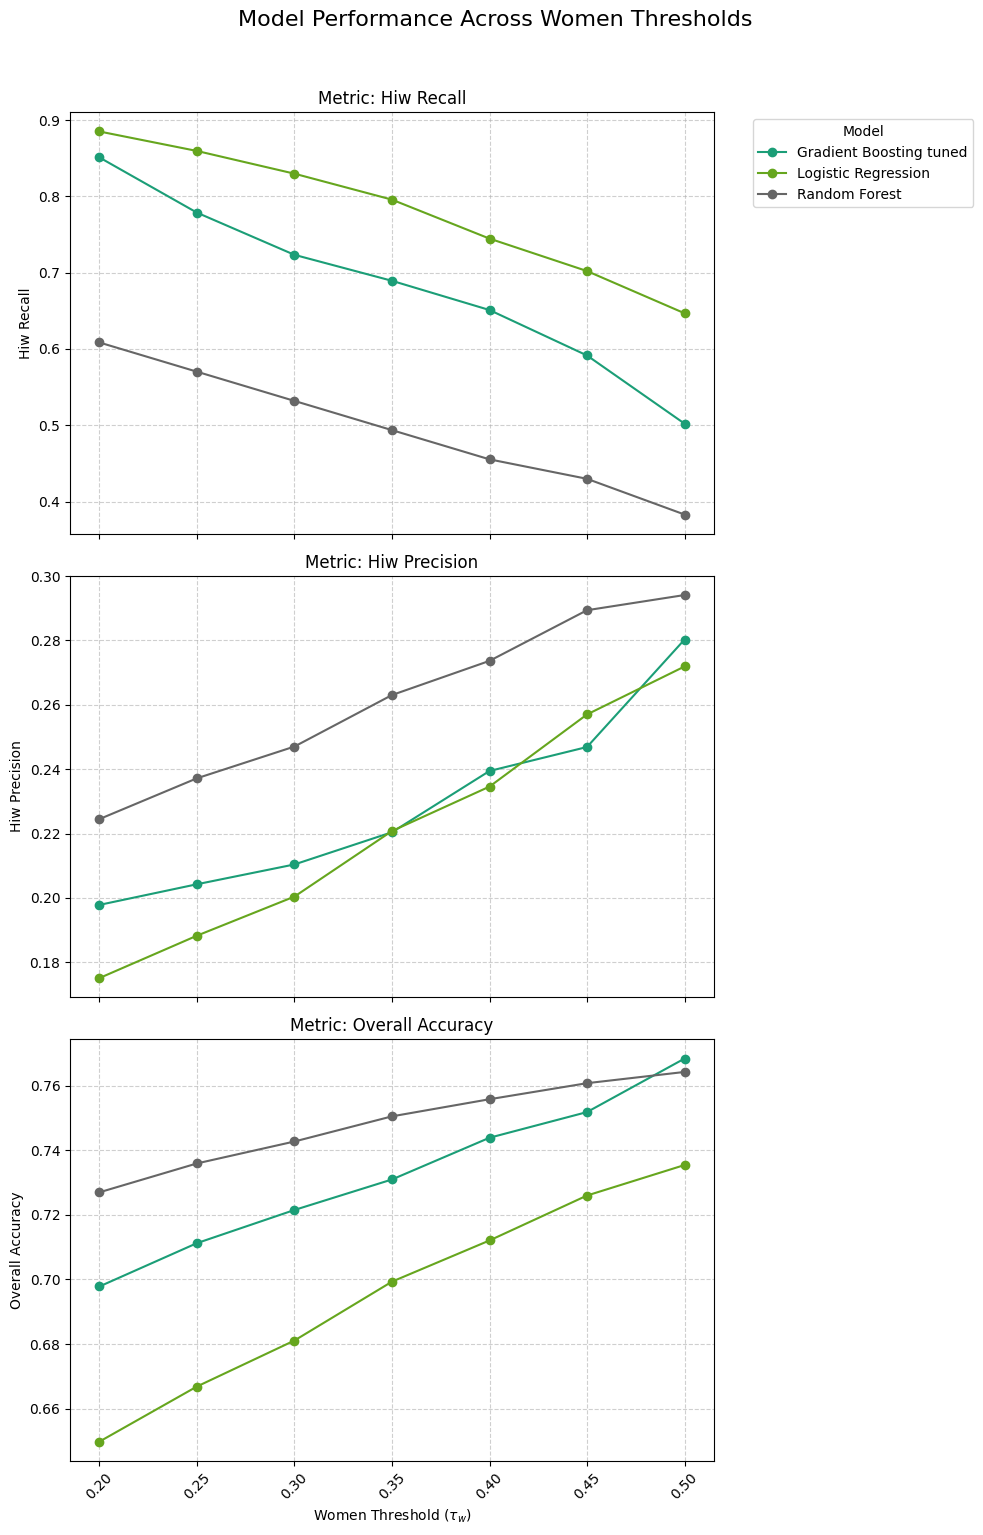

In [ ]:
if 'df_comparison' in locals():
    comparison_cols = ['hiw_recall', 'hiw_precision', 'overall_accuracy']
    
    # Extract model names and thresholds from DF
    models = df_comparison.columns.get_level_values('model').unique().tolist()
    thresholds = df_comparison.index.values

    # Create a figure for the 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    fig.suptitle('Model Performance Across Women Thresholds', fontsize=16, y=1.02)

    colors = plt.cm.Dark2(np.linspace(0, 1, len(models)))

    for i, metric in enumerate(comparison_cols):
        ax = axes[i]
        
        # Plotting each model's line for the current metric
        for j, model in enumerate(models):
            if (metric, model) in df_comparison.columns:
                ax.plot(
                    thresholds, 
                    df_comparison[metric][model], 
                    marker='o', 
                    linestyle='-', 
                    label=model.replace('_preds', '').replace('_', ' '),
                    color=colors[j]
                )
                
        # Set titles and labels
        ax.set_title(f'Metric: {metric.replace("_", " ").title()}', fontsize=12)
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Place legend 
        if i == 0:
            ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[-1].set_xlabel('Women Threshold ($\\tau_w$)')
    axes[-1].set_xticks(thresholds)
    axes[-1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('model_comparison_plot.png')

    print("Plot saved as model_comparison_plot.png")

else:
    print("Error: The DataFrame 'df_comparison' is not defined")

In [29]:
idx_max_f1 = df_all_unique['hiw_f1'].idxmax()
best_result = df_all_unique.loc[idx_max_f1]
print(best_result)

women_threshold                           0.5
hiw_recall                           0.646809
hiw_precision                        0.271914
hiw_f1                               0.382872
hiw_total                                 235
hiw_correct                               152
him_recall                           0.778216
liw_specificity                      0.234853
lim_specificity                      0.294853
overall_accuracy                     0.735455
model               Logistic Regression_preds
Name: 13, dtype: object


In [30]:
df_precision_only = df_comparison['hiw_precision']
print(df_precision_only)

model            Gradient Boosting_tuned_preds  Logistic Regression_preds  \
women_threshold                                                             
0.20                                  0.197824                   0.175084   
0.25                                  0.204241                   0.188257   
0.30                                  0.210396                   0.200411   
0.35                                  0.220408                   0.220779   
0.40                                  0.239437                   0.234584   
0.45                                  0.246892                   0.257009   
0.50                                  0.280285                   0.271914   

model            Random Forest_preds  
women_threshold                       
0.20                        0.224490  
0.25                        0.237168  
0.30                        0.247036  
0.35                        0.263039  
0.40                        0.273657  
0.45                        0.289

As Precision reduces and recall increases the F1 score drops however in a fairness audit as the one I am conducting it is better to have false negatives rather than false positives thus I will prioritise Recall for each model in comparison to F1 and make a moderate tradeoff where i will try to not let accuracy suffer too much.

In [46]:
#logregressionthreshold = 0.4
#gradientboostingthrehsold = 0.35
#randomforestthrehsold = 0.3
baseline_df = df_all_unique[df_all_unique['women_threshold']==0.5]

adj_df = df_all_unique[((df_all_unique['women_threshold']==0.4)&(df_all_unique['model']=='Logistic Regression_preds'))|
                                 ((df_all_unique['women_threshold']==0.35)&(df_all_unique['model']=='Gradient Boosting_tuned_preds'))|
                                 ((df_all_unique['women_threshold']==0.30)&(df_all_unique['model']=='Random Forest_preds'))]

comparison_df = baseline_df.merge(adj_df, how = 'inner', on = 'model', suffixes = ('_baseline','_adjusted'))

#Calculate Differences
comparison_df['delta_hiw_recall'] = comparison_df['hiw_recall_adjusted'] - comparison_df['hiw_recall_baseline']
comparison_df['delta_accuracy'] = comparison_df['overall_accuracy_baseline'] - comparison_df['overall_accuracy_adjusted']  # FLIPPED
comparison_df['additional_women'] = comparison_df['hiw_correct_adjusted'] - comparison_df['hiw_correct_baseline']
comparison_df.head()

,women_threshold_baseline,hiw_recall_baseline,hiw_precision_baseline,hiw_f1_baseline,hiw_total_baseline,hiw_correct_baseline,him_recall_baseline,liw_specificity_baseline,lim_specificity_baseline,overall_accuracy_baseline,...,hiw_f1_adjusted,hiw_total_adjusted,hiw_correct_adjusted,him_recall_adjusted,liw_specificity_adjusted,lim_specificity_adjusted,overall_accuracy_adjusted,delta_hiw_recall,delta_accuracy,additional_women
0,0.5,0.502128,0.280285,0.359756,235,118,0.701657,0.174841,0.214081,0.768440,...,0.334021,235,162,0.701657,0.330641,0.214081,0.730980,0.187234,0.037461,44
1,0.5,0.646809,0.271914,0.382872,235,152,0.778216,0.234853,0.294853,0.735455,...,0.356779,235,175,0.778216,0.329486,0.294853,0.712084,0.097872,0.023371,23
2,0.5,0.382979,0.294118,0.332717,235,90,0.502762,0.124639,0.154039,0.764296,...,0.337382,235,125,0.502762,0.219850,0.154039,0.742748,0.148936,0.021548,35


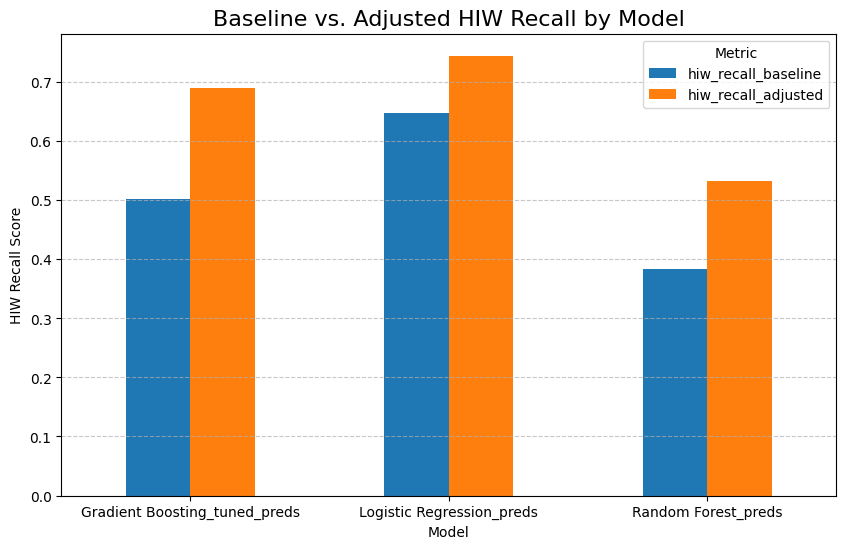

In [44]:
plot_df = comparison_df.set_index('model')[['hiw_recall_baseline','hiw_recall_adjusted']]
plot_df.plot(kind='bar',figsize=(10,6),rot=0)

plt.title('Baseline vs. Adjusted HIW Recall by Model', fontsize=16)
plt.ylabel('HIW Recall Score')
plt.xlabel('Model')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

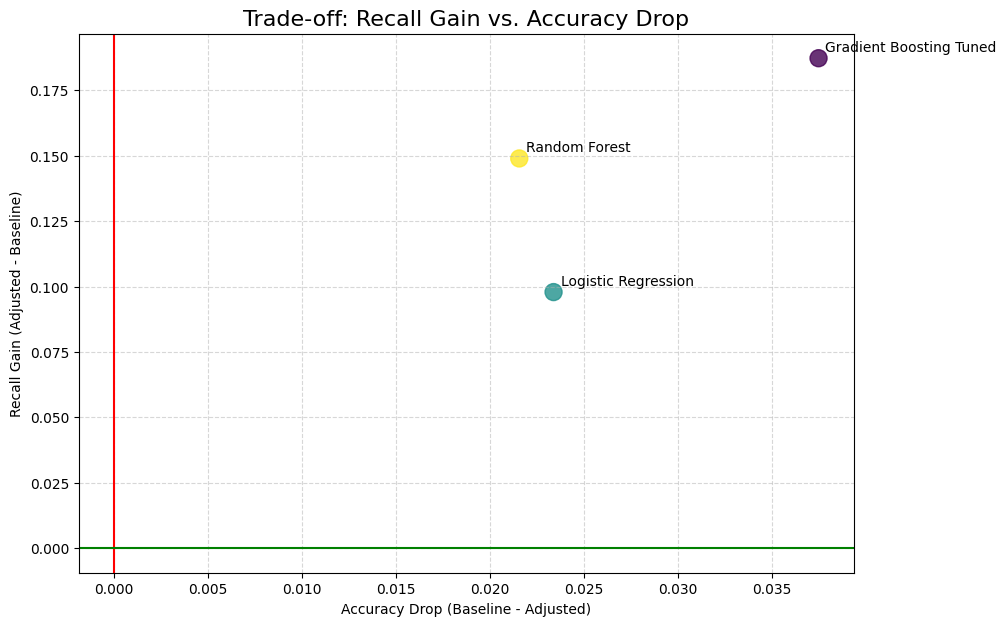

In [47]:
plt.figure(figsize=(10, 7))
plt.scatter(
    comparison_df['delta_accuracy'],
    comparison_df['delta_hiw_recall'],
    s=150, 
    c=np.arange(len(comparison_df)),
    cmap='viridis',
    alpha=0.8
)
# Add model labels next to points
for idx, row in comparison_df.iterrows():
    plt.annotate(
        row['model'].replace('_preds', '').replace('_tuned', ' Tuned'),  # Clean name
        (row['delta_accuracy'], row['delta_hiw_recall']),
        xytext=(5, 5),  # Offset label slightly
        textcoords='offset points',
        fontsize=10
    )


plt.title('Trade-off: Recall Gain vs. Accuracy Drop', fontsize=16)
plt.xlabel('Accuracy Drop (Baseline - Adjusted)')
plt.ylabel('Recall Gain (Adjusted - Baseline)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.axvline(x=0, color='r', linestyle='-') # Line for zero accuracy drop
plt.axhline(y=0, color='g', linestyle='-') # Line for zero recall gain
plt.show()

Gradient Boosting: +18.7% recall gain, -3.7% accuracy drop, 44 more women correctly identified

Random Forest: +14.9% recall gain, -1.8% accuracy drop, 35 more women correctly identified

Logistic Regression: +9.8% recall gain, -2.3% accuracy drop, 23 more women correctly identified